In [3]:
import pandas as pd

df = pd.read_csv("Customer_Churn_Dataset.csv")
df.head()

,Age,Tenure,MonthlyCharges,Contract,InternetService,SupportCalls,Churn
0,56,8,32,One year,Fiber,7,Yes
1,46,24,99,One year,DSL,4,Yes
2,32,11,101,Two year,DSL,6,No
3,60,51,56,One year,Fiber,3,No
4,25,17,38,Month-to-month,No,0,No


In [4]:
df.isnull().sum()

,0
Age,0
Tenure,0
MonthlyCharges,0
Contract,0
InternetService,0
SupportCalls,0
Churn,0


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              100 non-null    int64 
 1   Tenure           100 non-null    int64 
 2   MonthlyCharges   100 non-null    int64 
 3   Contract         100 non-null    object
 4   InternetService  100 non-null    object
 5   SupportCalls     100 non-null    int64 
 6   Churn            100 non-null    object
dtypes: int64(4), object(3)
memory usage: 5.6+ KB


,Age,Tenure,MonthlyCharges,SupportCalls
count,100.00000,100.000000,100.000000,100.000000
mean,40.88000,30.340000,71.770000,3.180000
std,13.99082,16.643754,27.142294,2.284688
min,18.00000,1.000000,30.000000,0.000000
25%,30.50000,15.000000,48.000000,1.000000
50%,41.00000,32.000000,72.000000,3.000000
75%,53.25000,42.250000,96.250000,5.000000
max,64.00000,59.000000,119.000000,7.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
import numpy as np
import matplotlib.pyplot as plt



Churn
Yes    58
No     42
Name: count, dtype: int64


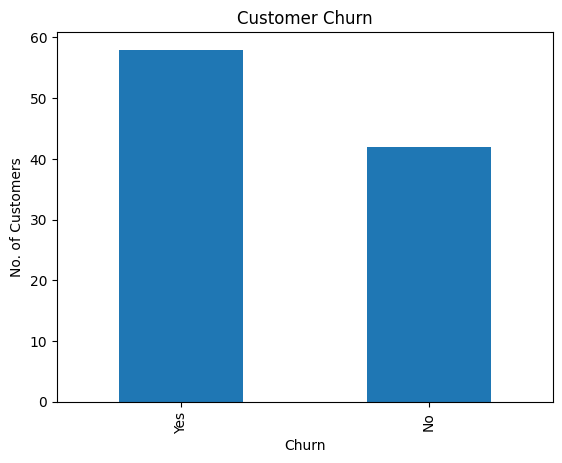

In [8]:
a = df["Churn"].value_counts()
print(a)
a.plot(kind = "bar")

plt.title("Customer Churn")
plt.xlabel("Churn")
plt.ylabel("No. of Customers")
plt.show()

In [9]:
X = df.drop("Churn", axis = 1)
y = df["Churn"]

In [10]:
X = pd.get_dummies(X,columns=["Contract","InternetService"], drop_first=True)
y = y.map({"No": 0 ,"Yes": 1})

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(x_train_scaled, y_train)
log_pred = log_model.predict(x_test_scaled)

In [14]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

log_acc = accuracy_score(y_test , log_pred)
log_pre = precision_score(y_test , log_pred)
log_recall = recall_score(y_test , log_pred)
log_f1 = f1_score(y_test , log_pred)

print("Accuracy:", log_acc)
print("Precision:", log_pre)
print("Recall:", log_recall)
print("f1:", log_f1)

Accuracy: 0.35
Precision: 0.46153846153846156
Recall: 0.5
f1: 0.48


In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state = 42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

dt_acc = accuracy_score(y_test , dt_pred)
dt_pre = precision_score(y_test , dt_pred)
dt_recall = recall_score(y_test , dt_pred)
dt_f1 = f1_score(y_test , dt_pred)

print("Accuracy:", dt_acc)
print("Precision:", dt_pre)
print("Recall:", dt_recall)
print("f1:", dt_f1)

Accuracy: 0.4
Precision: 0.5
Recall: 0.5
f1: 0.5


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

rf_acc = accuracy_score(y_test , rf_pred)
rf_pre = precision_score(y_test , rf_pred)
rf_recall = recall_score(y_test , rf_pred)
rf_f1 = f1_score(y_test , rf_pred)

print("Accuracy:", rf_acc)
print("Precision:", rf_pre)
print("Recall:", rf_recall)
print("f1:", rf_f1)

Accuracy: 0.35
Precision: 0.45454545454545453
Recall: 0.4166666666666667
f1: 0.43478260869565216


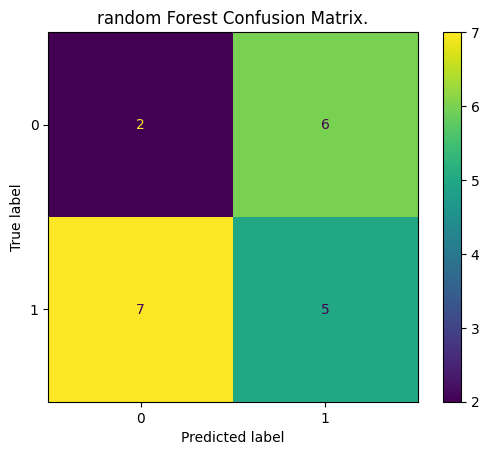

In [19]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm = confusion_matrix(y_test , rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.title("random Forest Confusion Matrix.")
plt.show()

In [24]:
comparison = pd.DataFrame({
  "Model" : ["Logistic", "DecisionTree", "RandomForest"],
  "AC" : [log_acc,dt_acc, rf_acc],
  "PS": [log_pre,dt_pre,rf_pre],
  "Recall" : [log_recall, dt_recall, rf_recall],
  "F1" : [log_f1, dt_f1, rf_f1]
})
comparison

,Model,AC,PS,Recall,F1
0,Logistic,0.35,0.461538,0.500000,0.480000
1,DecisionTree,0.40,0.500000,0.500000,0.500000
2,RandomForest,0.35,0.454545,0.416667,0.434783


In [26]:
import matplotlib.pyplot as plt

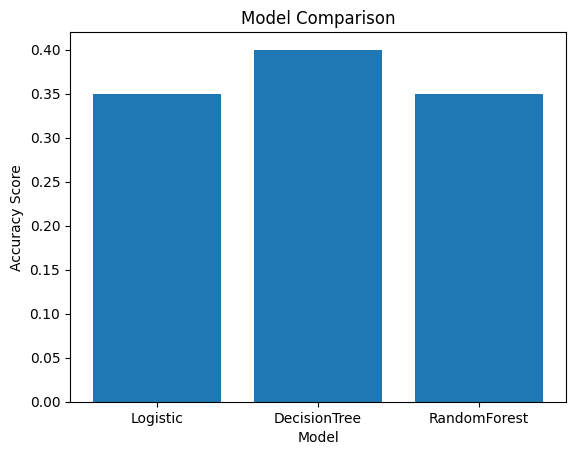

In [29]:
plt.bar(comparison["Model"], comparison["AC"])
plt.xlabel("Model")
plt.ylabel("Accuracy Score")
plt.title("Model Comparison")

plt.show()

In [30]:
new_customer = pd.DataFrame({
    "Age": [30],
    "Tenure": [5],
    "MonthlyCharges": [80],
    "SupportCalls": [4],
    "Contract_One year": [0],
    "Contract_Two year": [0],
    "InternetService_Fiber": [1],
    "InternetService_No": [0]
})

In [31]:
new_customer = new_customer[X.columns]
new_cust_scaled = scaler.transform(new_customer)
prediction = log_model.predict(new_cust_scaled)

if prediction[0] == 1:
  print("Customer is likely to churn")
else:
  print("Customer is unlikely to churn")

Customer is likely to churn
